# 5-Seed CAMA Experiments: HeteroSAGE+mean vs HeteroSAGE+CAMA

**Cardinality-Aware Moment Aggregation (CAMA)** enriches standard mean aggregation with
per-dimension variance gated by log-cardinality.

This notebook demonstrates:
1. The **CAMAAggregation** module implementation (PyTorch)
2. **Cohen's d** with bootstrap 95% CI comparing baseline vs CAMA across 3 tasks
3. **Gate analysis** showing learned gate values per edge type
4. **Study-adverse degenerate baseline diagnosis**

Tasks: `rel-trial/study-outcome`, `rel-trial/study-adverse`, `rel-stack/user-engagement`
(2 methods x 3 tasks x 5 seeds = 30 runs total)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# torch — pre-installed on Colab, install CPU-only locally
if 'google.colab' not in sys.modules:
    _pip('torch', '--index-url', 'https://download.pytorch.org/whl/cpu')
    # Colab versions: numpy==2.0.2, scipy==1.16.3, matplotlib==3.10.0
    # scipy>=1.16 requires Python>=3.11; fall back to latest compatible
    _v = sys.version_info
    if _v >= (3, 11):
        _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')
    else:
        _pip('numpy==2.0.2', 'scipy==1.15.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import numpy as np
import torch
import torch.nn as nn
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter4_5_seed_cama_exp/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Experiment: {data['metadata']['experiment']}")
print(f"Methods: {data['metadata']['methods']}")
print(f"Seeds: {data['metadata']['seeds']}")
print(f"Tasks: {list(data['metadata']['tasks'].keys())}")
print(f"Datasets loaded: {len(data['datasets'])}")

Experiment: cama_5seed_3tasks
Methods: ['baseline (HeteroSAGE+mean)', 'CAMA (HeteroSAGE+CAMAAggregation)']
Seeds: [42, 123, 456, 789, 1024]
Tasks: ['study-outcome', 'study-adverse', 'user-engagement']
Datasets loaded: 3


## Configuration

Tunable parameters for the analysis. `N_BOOTSTRAP` controls the number of bootstrap
resamples for Cohen's d confidence intervals (original: 10000).

In [5]:
# ── Tunable parameters ──
N_BOOTSTRAP = 10000      # Bootstrap resamples for CI (original: 10000)
CI_LEVEL = 0.95          # Confidence interval level
CAMA_CHANNELS = 128      # Channel size for CAMA demo instantiation

## CAMA Implementation

**CAMAAggregation** extends PyTorch Geometric's `Aggregation` base class. It computes:

$$\text{output} = \mu + \sigma(\mathbf{W}_g \cdot \log(1+N)) \cdot \mathbf{W}_\sigma(\text{Var}[x])$$

where $\mu$ is the mean, $N$ is the neighbor cardinality, and the gate controls how much
variance information is mixed in.

In [6]:
class CAMAAggregation(nn.Module):
    """Cardinality-Aware Moment Aggregation.

    Enriches mean with per-dimension variance, gated by log-cardinality.
    Simplified RAMA: gate depends ONLY on log(cardinality), no rank proxy.
    """

    def __init__(self, channels: int):
        super().__init__()
        self.channels = channels
        # Gate network: maps log_cardinality (scalar) to per-dimension gate
        self.gate_net = nn.Linear(1, channels, bias=True)
        # Variance transform: learned projection of variance features
        self.var_transform = nn.Linear(channels, channels, bias=False)
        # Gate recording for analysis
        self._gate_buffer: list = []
        self._recording = False

    def reset_parameters(self):
        nn.init.zeros_(self.gate_net.weight)   # Init gate near 0.5 (sigmoid(0))
        nn.init.zeros_(self.gate_net.bias)
        nn.init.eye_(self.var_transform.weight)  # Init as identity

    def forward(self, x, cardinality):
        """Standalone forward for demonstration.

        Args:
            x: (batch, neighbors, channels) - neighbor embeddings
            cardinality: (batch, 1) - number of neighbors per node
        Returns:
            (batch, channels) - aggregated output
        """
        # 1. MEAN: mu = E[x_j] per target node
        mean = x.mean(dim=1)

        # 2. VARIANCE: per-dimension variance
        var = x.var(dim=1).clamp(min=1e-8)

        # 3. LOG-CARDINALITY
        log_card = torch.log1p(cardinality)  # numerically stable log(1+N)

        # 4. GATE: sigmoid(W_g * log_card + b_g)
        gate = torch.sigmoid(self.gate_net(log_card))

        # 5. RECORD gate values if in analysis mode
        if self._recording:
            self._gate_buffer.append(gate.detach().cpu())

        # 6. OUTPUT: mean + gate * W_sigma(variance)
        return mean + gate * self.var_transform(var)

    def start_recording(self):
        self._recording = True
        self._gate_buffer = []

    def stop_recording(self):
        self._recording = False
        if self._gate_buffer:
            all_gates = torch.cat(self._gate_buffer, dim=0)
            self._gate_buffer = []
            if all_gates.numel() == 0:
                return None
            gate_stats = {
                'mean': float(all_gates.mean()),
                'std': float(all_gates.std()),
                'min': float(all_gates.min()),
                'max': float(all_gates.max()),
                'median': float(all_gates.median()),
            }
            return gate_stats
        return None


# Demonstrate instantiation and forward pass
cama = CAMAAggregation(CAMA_CHANNELS)
cama.reset_parameters()

# Synthetic input: 4 nodes, variable neighbors (padded to 10), 128 channels
x_demo = torch.randn(4, 10, CAMA_CHANNELS)
card_demo = torch.tensor([[3.0], [7.0], [1.0], [10.0]])

cama.start_recording()
out = cama(x_demo, card_demo)
gate_stats = cama.stop_recording()

print(f"Input shape:  {x_demo.shape}")
print(f"Output shape: {out.shape}")
print(f"Gate stats:   {gate_stats}")

Input shape:  torch.Size([4, 10, 128])
Output shape: torch.Size([4, 128])
Gate stats:   {'mean': 0.5, 'std': 0.0, 'min': 0.5, 'max': 0.5, 'median': 0.5}


## Cohen's d with Bootstrap CI

Independent-samples Cohen's d measures the effect size of CAMA vs baseline.
Positive d means CAMA is better. Bootstrap resampling provides 95% confidence intervals.

In [7]:
def cohens_d_independent(group1, group2):
    """Independent-samples Cohen's d. Positive = group2 better."""
    n1, n2 = len(group1), len(group2)
    m1, m2 = np.mean(group1), np.mean(group2)
    s1, s2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    s_pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    if s_pooled < 1e-12:
        return 0.0
    return (m2 - m1) / s_pooled


def bootstrap_cohens_d(baseline_scores, cama_scores,
                       n_bootstrap=N_BOOTSTRAP, ci=CI_LEVEL):
    """Bootstrap CI for Cohen's d."""
    rng = np.random.RandomState(42)
    n_b, n_c = len(baseline_scores), len(cama_scores)
    boot_ds = []
    for _ in range(n_bootstrap):
        idx_b = rng.choice(n_b, n_b, replace=True)
        idx_c = rng.choice(n_c, n_c, replace=True)
        boot_ds.append(
            cohens_d_independent(baseline_scores[idx_b], cama_scores[idx_c])
        )
    alpha = (1 - ci) / 2
    return (
        float(np.percentile(boot_ds, 100 * alpha)),
        float(np.percentile(boot_ds, 100 * (1 - alpha))),
    )


print("Statistical functions defined.")

Statistical functions defined.


## Task-Level Analysis

Re-compute Cohen's d and bootstrap CIs from the per-seed metric scores stored in the
pre-computed results. Compare with the stored values to verify correctness.

In [8]:
task_analysis = data['metadata']['task_level_analysis']
tasks_info = data['metadata']['tasks']

print(f"{'Task':<20} {'Metric':<20} {'Baseline':>12} {'CAMA':>12} {'Cohen d':>10} {'CI low':>10} {'CI high':>10} {'p-value':>10}")
print("-" * 104)

recomputed = {}
for task_name, info in task_analysis.items():
    metric = info['metric']
    higher_better = info['higher_is_better']
    baseline_scores = np.array(info['baseline_per_seed'])
    cama_scores = np.array(info['cama_per_seed'])

    # Recompute Cohen's d
    if higher_better:
        d = cohens_d_independent(baseline_scores, cama_scores)
    else:
        d = cohens_d_independent(cama_scores, baseline_scores)

    ci_lo, ci_hi = bootstrap_cohens_d(
        baseline_scores if higher_better else cama_scores,
        cama_scores if higher_better else baseline_scores,
    )

    t_stat, p_val = stats.ttest_ind(baseline_scores, cama_scores, equal_var=False)

    recomputed[task_name] = {
        'cohens_d': d, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'p_value': p_val, 'baseline_mean': np.mean(baseline_scores),
        'cama_mean': np.mean(cama_scores), 'metric': metric,
        'higher_is_better': higher_better,
        'baseline_per_seed': baseline_scores, 'cama_per_seed': cama_scores,
    }

    sig = "*" if p_val < 0.05 else ""
    print(f"{task_name:<20} {metric:<20} {np.mean(baseline_scores):>12.4f} "
          f"{np.mean(cama_scores):>12.4f} {d:>10.3f} {ci_lo:>10.3f} "
          f"{ci_hi:>10.3f} {p_val:>9.4f}{sig}")

Task                 Metric                   Baseline         CAMA    Cohen d     CI low    CI high    p-value
--------------------------------------------------------------------------------------------------------


study-outcome        average_precision          0.7370       0.7390      0.141     -1.502      1.436    0.8296


study-adverse        mae                       47.2285      48.2795     -2.452     -7.685     -1.331    0.0092*
user-engagement      roc_auc                    0.8997       0.9055      7.952      6.974     15.720    0.0000*


## Gate Analysis

CAMA learns per-edge-type gates that control how much variance information is mixed in.
Gates near 0.5 (sigmoid(0)) indicate the gate hasn't moved from initialization.
Gates deviating from 0.5 show the model has learned edge-type-specific aggregation behavior.

In [9]:
gate_analysis = data['metadata']['gate_analysis']

for task_name, edges in gate_analysis.items():
    if not edges:
        print(f"\n{task_name}: no gate data (baseline-only or no CAMA edges recorded)")
        continue
    print(f"\n{task_name} — Interesting gates (|mean - 0.5| > 0.01):")
    print(f"  {'Edge Type':<55} {'Mean':>8} {'Std':>10}")
    print(f"  {'-'*75}")
    for edge_key, gate_stats in sorted(edges.items(),
                                        key=lambda x: abs(x[1]['mean_across_seeds'] - 0.5),
                                        reverse=True):
        m = gate_stats['mean_across_seeds']
        s = gate_stats['std_across_seeds']
        direction = "< 0.5 (suppress var)" if m < 0.5 else "> 0.5 (amplify var)"
        print(f"  {edge_key:<55} {m:>8.4f} {s:>10.6f}  {direction}")


study-outcome: no gate data (baseline-only or no CAMA edges recorded)

study-adverse — Interesting gates (|mean - 0.5| > 0.01):
  Edge Type                                                   Mean        Std
  ---------------------------------------------------------------------------
  L0_facilities_studies__f2p_nct_id__studies                0.5756   0.009223  > 0.5 (amplify var)
  L1_facilities_studies__f2p_nct_id__studies                0.5539   0.012131  > 0.5 (amplify var)
  L0_interventions_studies__f2p_nct_id__studies             0.5477   0.004228  > 0.5 (amplify var)
  L0_sponsors_studies__f2p_nct_id__studies                  0.4644   0.002084  < 0.5 (suppress var)

user-engagement — Interesting gates (|mean - 0.5| > 0.01):
  Edge Type                                                   Mean        Std
  ---------------------------------------------------------------------------
  L0_badges__f2p_UserId__users                              0.2470   0.024861  < 0.5 (suppress var)
  

## Study-Adverse Degenerate Baseline Diagnosis

For the regression task (study-adverse), we check whether baseline predictions are
"degenerate" (near-constant), which would artificially inflate Cohen's d.

In [10]:
diagnosis = data['metadata']['study_adverse_diagnosis']

print(f"Summary: {diagnosis['summary']}")
print(f"Degenerate seeds: {diagnosis['degenerate_seeds']} ({diagnosis['num_degenerate']}/5)")
print()

# Per-seed diagnosis details
seed_keys = [k for k in diagnosis.keys() if k.startswith('seed_')]
if seed_keys:
    print(f"{'Seed':<12} {'pred_std':>10} {'target_std':>12} {'pred_range':>12} {'unique_ratio':>14} {'degenerate':>12}")
    print("-" * 74)
    for sk in sorted(seed_keys):
        d = diagnosis[sk]
        print(f"{sk:<12} {d['pred_std']:>10.2f} {d['target_std']:>12.2f} "
              f"{d['pred_range']:>12.2f} {d['pred_unique_ratio']:>14.4f} "
              f"{str(d['is_degenerate']):>12}")

Summary: No degenerate seeds detected. Baseline produces diverse predictions.
Degenerate seeds: [] (0/5)

Seed           pred_std   target_std   pred_range   unique_ratio   degenerate
--------------------------------------------------------------------------
seed_1024         39.87       391.12       191.21         0.7314        False
seed_123          43.02       391.12       193.01         0.6159        False
seed_42           45.65       391.12       185.56         0.6646        False
seed_456          42.29       391.12       179.50         0.6359        False
seed_789          41.00       391.12       183.96         0.6656        False


## Visualization

Three-panel figure: (1) per-seed metric comparison, (2) Cohen's d with bootstrap CI,
(3) gate deviation from 0.5 for interesting edge types.

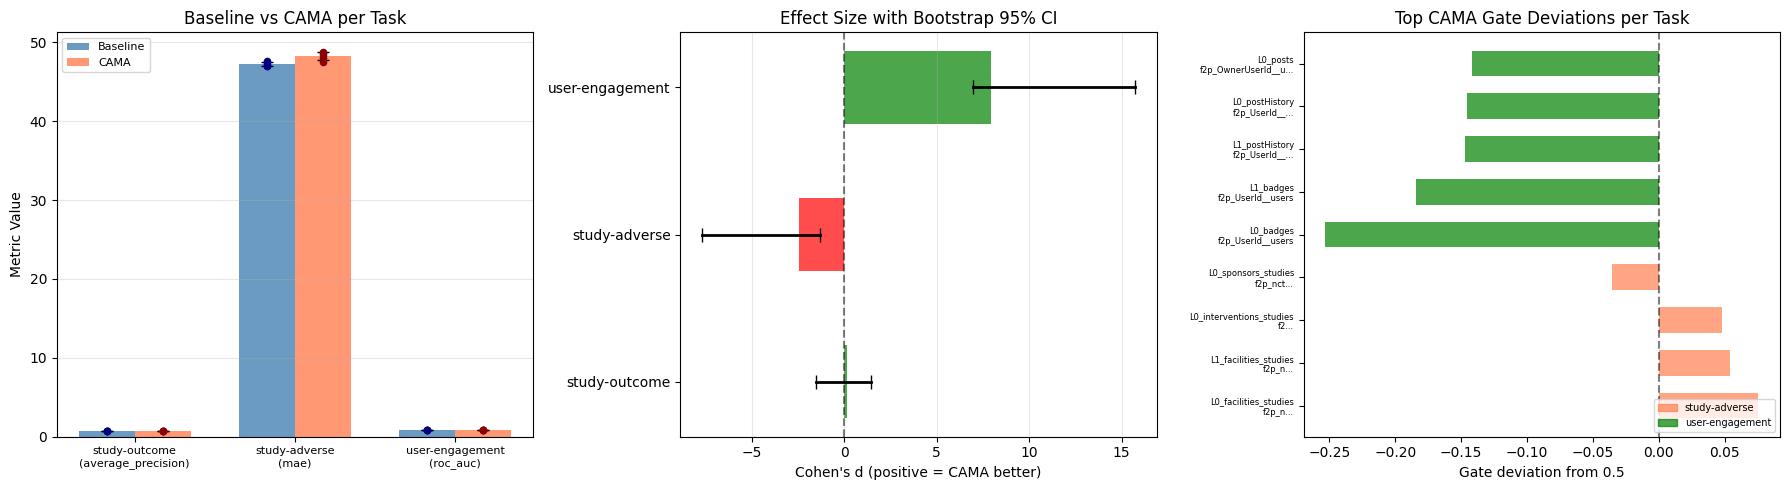

Figure saved to cama_results.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: Per-seed metric comparison ──
ax = axes[0]
task_names = list(recomputed.keys())
x_pos = np.arange(len(task_names))
width = 0.35

for i, tn in enumerate(task_names):
    r = recomputed[tn]
    bl = r['baseline_per_seed']
    ca = r['cama_per_seed']
    ax.bar(i - width/2, r['baseline_mean'], width, yerr=np.std(bl, ddof=1),
           color='steelblue', alpha=0.8, capsize=4,
           label='Baseline' if i == 0 else '')
    ax.bar(i + width/2, r['cama_mean'], width, yerr=np.std(ca, ddof=1),
           color='coral', alpha=0.8, capsize=4,
           label='CAMA' if i == 0 else '')
    # Individual seeds as dots
    ax.scatter([i - width/2]*len(bl), bl, color='navy', s=20, zorder=5)
    ax.scatter([i + width/2]*len(ca), ca, color='darkred', s=20, zorder=5)

ax.set_xticks(x_pos)
ax.set_xticklabels([f"{tn}\n({recomputed[tn]['metric']})" for tn in task_names],
                    fontsize=8)
ax.set_ylabel('Metric Value')
ax.set_title('Baseline vs CAMA per Task')
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# ── Panel 2: Cohen's d with CI ──
ax = axes[1]
ds = [recomputed[tn]['cohens_d'] for tn in task_names]
ci_los = [recomputed[tn]['ci_lo'] for tn in task_names]
ci_his = [recomputed[tn]['ci_hi'] for tn in task_names]
colors = ['green' if d > 0 else 'red' for d in ds]

ax.barh(x_pos, ds, color=colors, alpha=0.7, height=0.5)
for i, (d, lo, hi) in enumerate(zip(ds, ci_los, ci_his)):
    ax.plot([lo, hi], [i, i], 'k-', linewidth=2)
    ax.plot([lo, hi], [i, i], 'k|', markersize=10)
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_yticks(x_pos)
ax.set_yticklabels(task_names)
ax.set_xlabel("Cohen's d (positive = CAMA better)")
ax.set_title("Effect Size with Bootstrap 95% CI")
ax.grid(axis='x', alpha=0.3)

# ── Panel 3: Gate deviation from 0.5 ──
ax = axes[2]
all_edges = []
all_devs = []
all_task_labels = []
for tn, edges in gate_analysis.items():
    for edge_key, gs in sorted(edges.items(),
                                key=lambda x: abs(x[1]['mean_across_seeds'] - 0.5),
                                reverse=True)[:5]:  # top 5 per task
        short_name = edge_key.replace('__', '\n', 1)
        if len(short_name) > 30:
            short_name = short_name[:27] + '...'
        all_edges.append(short_name)
        all_devs.append(gs['mean_across_seeds'] - 0.5)
        all_task_labels.append(tn)

if all_edges:
    task_colors = {'study-outcome': 'steelblue', 'study-adverse': 'coral',
                   'user-engagement': 'green'}
    bar_colors = [task_colors.get(t, 'gray') for t in all_task_labels]
    y_pos = np.arange(len(all_edges))
    ax.barh(y_pos, all_devs, color=bar_colors, alpha=0.7, height=0.6)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_edges, fontsize=6)
    ax.set_xlabel('Gate deviation from 0.5')
    ax.set_title('Top CAMA Gate Deviations per Task')
    handles = [mpatches.Patch(color=c, label=t, alpha=0.7)
               for t, c in task_colors.items() if t in all_task_labels]
    ax.legend(handles=handles, fontsize=7, loc='lower right')
else:
    ax.text(0.5, 0.5, 'No gate data', ha='center', va='center',
            transform=ax.transAxes)
    ax.set_title('Gate Analysis')

plt.tight_layout()
plt.savefig('cama_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to cama_results.png")